# Hidden-State Evidence Extraction

This notebook orchestrates the end-to-end experiment for the two proposal variants:
- Frozen causal LM backbone + linear evidence head
- Frozen bidirectional encoder backbone + linear evidence head

All reusable logic lives in `src/`; this notebook only handles configuration, training runs, comparison, and quick error analysis.


In [1]:
from functools import partial
from pathlib import Path

from torch.utils.data import DataLoader

from src.config import ExperimentConfig
from src.data import dataset_statistics, estimate_token_length_stats, load_or_prepare_hotpotqa
from src.modeling import (
    HiddenStateEvidenceClassifier,
    collate_batch,
    get_hidden_size,
    load_backbone_and_tokenizer,
    tokenize_dataset,
)
from src.train_eval import estimate_pos_weight, evaluate_and_save, train_classifier
from src.utils import format_metrics_table, get_device, set_seed

In [2]:
config = ExperimentConfig.default()
config.data.cache_dir = Path("artifacts/cache/hotpotqa_distractor")
config.train.output_dir = Path("artifacts/runs")
config.data.max_train_examples = 10_000
config.data.max_validation_examples = 2_000

# Override defaults here if needed.
config.train.batch_size = 64
config.train.epochs = 5
config.train.patience = 2
config.models["causal"].max_length = 3072
config.models["bidirectional"].max_length = 3072

device = get_device()
set_seed(config.train.seed)
print({
    "device": device,
    "causal_model": config.models["causal"].model_name_or_path,
    "bidirectional_model": config.models["bidirectional"].model_name_or_path,
    "max_train_examples": config.data.max_train_examples,
    "max_validation_examples": config.data.max_validation_examples,
})


{'device': 'cuda', 'causal_model': 'Qwen/Qwen3-0.6B', 'bidirectional_model': 'Qwen/Qwen3-Embedding-0.6B', 'max_train_examples': 10000, 'max_validation_examples': 2000}


In [3]:
dataset_splits = load_or_prepare_hotpotqa(config.data)
for split_name, rows in dataset_splits.items():
    print(split_name, dataset_statistics(rows))

train {'num_examples': 10000, 'num_positive_labels': 20000, 'num_negative_labels': 80000, 'positive_rate': 0.2, 'avg_question_chars': 105.7772, 'avg_passage_chars': 542.55703}
validation {'num_examples': 2000, 'num_positive_labels': 4000, 'num_negative_labels': 16000, 'positive_rate': 0.2, 'avg_question_chars': 107.564, 'avg_passage_chars': 545.5249}
test {'num_examples': 7345, 'num_positive_labels': 14690, 'num_negative_labels': 58760, 'positive_rate': 0.2, 'avg_question_chars': 92.5066031313819, 'avg_passage_chars': 550.0280462899932}


In [4]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(config.models["causal"].model_name_or_path, trust_remote_code=True)
for split_name, rows in dataset_splits.items():
    stats = estimate_token_length_stats(rows, tokenizer)
    print(f"{split_name}: mean={stats['mean']:.0f}, min={stats['min']}, max={stats['max']}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


train: mean=1492, min=751, max=2494
validation: mean=1497, min=813, max=2749
test: mean=1469, min=740, max=3047


In [5]:
def build_loader(rows, tokenizer, model_config, batch_size, shuffle):
    tokenized_rows = tokenize_dataset(rows, tokenizer, model_config)
    loader = DataLoader(
        tokenized_rows,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=partial(collate_batch, pad_token_id=tokenizer.pad_token_id),
    )
    return tokenized_rows, loader


def run_experiment(model_key):
    model_config = config.models[model_key]
    run_dir = config.train.output_dir / model_key

    backbone, tokenizer = load_backbone_and_tokenizer(model_config)

    _, train_loader = build_loader(
        dataset_splits["train"], tokenizer, model_config, config.train.batch_size, shuffle=True
    )
    _, validation_loader = build_loader(
        dataset_splits["validation"], tokenizer, model_config, config.train.batch_size, shuffle=False
    )
    _, test_loader = build_loader(
        dataset_splits["test"], tokenizer, model_config, config.train.batch_size, shuffle=False
    )

    model = HiddenStateEvidenceClassifier(
        backbone=backbone,
        hidden_size=get_hidden_size(backbone),
        pos_weight=estimate_pos_weight(dataset_splits["train"]),
    )
    training_summary = train_classifier(
        model=model,
        train_loader=train_loader,
        validation_loader=validation_loader,
        train_config=config.train,
        output_dir=run_dir,
        device=device,
    )
    test_results = evaluate_and_save(
        model=model,
        dataloader=test_loader,
        device=device,
        output_dir=run_dir,
        split_name="test",
        tuned_threshold=training_summary["best_threshold"],
    )

    return {
        "model_config": model_config,
        "training": training_summary,
        "test": test_results,
    }

In [6]:
causal_results = run_experiment("causal")
causal_results["test"]["tuned_threshold"]


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3Model LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training epoch 1/5:   0%|          | 0/157 [00:00<?, ?it/s]

Predicting:   0%|          | 0/32 [00:00<?, ?it/s]

Training epoch 2/5:   0%|          | 0/157 [00:00<?, ?it/s]

...

Predicting:   0%|          | 0/32 [00:00<?, ?it/s]

Training epoch 5/5:   0%|          | 0/157 [00:00<?, ?it/s]

Predicting:   0%|          | 0/32 [00:00<?, ?it/s]

Predicting:   0%|          | 0/115 [00:00<?, ?it/s]

{'threshold': 0.63,
 'overall': {'precision': 0.6320390081465184,
  'recall': 0.7235534377127297,
  'f1': 0.674707207922049},
 'by_question_type': {'bridge': {'precision': 0.6217842635775538,
   'recall': 0.7006272249533819,
   'f1': 0.6588554120835326},
  'comparison': {'precision': 0.6707351688901504,
   'recall': 0.8170816044260027,
   'f1': 0.7367108339828526}},
 'num_examples': 7345}

In [7]:
bidirectional_results = run_experiment("bidirectional")
bidirectional_results["test"]["tuned_threshold"]


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

Predicting:   0%|          | 0/32 [00:00<?, ?it/s]

Training epoch 5/5:   0%|          | 0/157 [00:00<?, ?it/s]

Predicting:   0%|          | 0/32 [00:00<?, ?it/s]

Predicting:   0%|          | 0/115 [00:00<?, ?it/s]

{'threshold': 0.66,
 'overall': {'precision': 0.56873720958228,
  'recall': 0.6432266848196052,
  'f1': 0.6036928188090979},
 'by_question_type': {'bridge': {'precision': 0.5540408958130477,
   'recall': 0.626970672995423,
   'f1': 0.5882540061235039},
  'comparison': {'precision': 0.6288691388292982,
   'recall': 0.7095435684647303,
   'f1': 0.6667749796913078}},
 'num_examples': 7345}

## Baselines: Dual-Tower & Cross-Encoder

In [10]:
from sentence_transformers import SentenceTransformer, CrossEncoder
import numpy as np
from tqdm.auto import tqdm
from src.train_eval import search_best_threshold, summarize_prediction_records
from src.modeling import build_passage_text
from src.utils import ensure_dir, save_json


def score_baseline(split_rows, score_fn, desc="Scoring"):
    """Score all examples in a split using a scoring function."""
    records = []
    for ex in tqdm(split_rows, desc=desc, leave=False):
        question = ex["question"]
        scores = score_fn(question, ex["passages"])
        records.append({
            "example_id": str(ex["example_id"]),
            "question_type": ex["question_type"],
            "labels": list(ex["labels"]),
            "probabilities": scores,
        })
    return records


def run_baseline(name, score_fn):
    run_dir = ensure_dir(config.train.output_dir / name)

    val_records = score_baseline(dataset_splits["validation"], score_fn, desc=f"{name} validation")
    test_records = score_baseline(dataset_splits["test"], score_fn, desc=f"{name} test")

    # Find best threshold on validation
    flat_labels = [l for r in val_records for l in r["labels"]]
    flat_probs = [p for r in val_records for p in r["probabilities"]]
    best = search_best_threshold(flat_labels, flat_probs)

    # Evaluate on test
    test_metrics = summarize_prediction_records(test_records, threshold=best["threshold"])
    save_json(test_records, run_dir / "test_predictions.json")
    save_json(test_metrics, run_dir / "test_metrics_tuned_threshold.json")

    print(f"[{name}] threshold={best['threshold']:.2f}, test F1={test_metrics['overall']['f1']:.4f}")
    return {"records": test_records, "tuned_threshold": test_metrics}

In [11]:
# Dual-Tower: encode query and passages independently, score by cosine similarity
dual_tower_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)

def dual_tower_score(question, passages):
    q_emb = dual_tower_model.encode(question, normalize_embeddings=True)
    p_texts = [f"{p['title']}: {p['text']}" for p in passages]
    p_embs = dual_tower_model.encode(p_texts, normalize_embeddings=True)
    scores = (p_embs @ q_emb).tolist()
    return scores

dual_tower_results = run_baseline("dual_tower", dual_tower_score)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


dual_tower validation:   0%|          | 0/2000 [00:00<?, ?it/s]

dual_tower test:   0%|          | 0/7345 [00:00<?, ?it/s]

[dual_tower] threshold=0.51, test F1=0.5191


In [12]:
# Cross-Encoder: score each (query, passage) pair independently
cross_encoder_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L6-v2", device=device)

def cross_encoder_score(question, passages):
    pairs = [(question, f"{p['title']}: {p['text']}") for p in passages]
    scores = cross_encoder_model.predict(pairs).tolist()
    # Normalize scores to [0, 1] with sigmoid
    scores = [1 / (1 + np.exp(-s)) for s in scores]
    return scores

cross_encoder_results = run_baseline("cross_encoder", cross_encoder_score)

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

cross_encoder validation:   0%|          | 0/2000 [00:00<?, ?it/s]

cross_encoder test:   0%|          | 0/7345 [00:00<?, ?it/s]

[cross_encoder] threshold=0.95, test F1=0.5783


In [13]:
comparison = {
    "dual_tower": dual_tower_results["tuned_threshold"],
    "cross_encoder": cross_encoder_results["tuned_threshold"],
    "causal": causal_results["test"]["tuned_threshold"],
    "bidirectional": bidirectional_results["test"]["tuned_threshold"],
}
print(format_metrics_table(comparison))

for name, result in comparison.items():
    print(f"\n{name} by question type")
    for question_type, metrics in result["by_question_type"].items():
        print(question_type, metrics)

model         | threshold | precision | recall | f1    
dual_tower    | 0.510     | 0.4772    | 0.5691 | 0.5191
cross_encoder | 0.950     | 0.5909    | 0.5662 | 0.5783
causal        | 0.630     | 0.6320    | 0.7236 | 0.6747
bidirectional | 0.660     | 0.5687    | 0.6432 | 0.6037

dual_tower by question type
bridge {'precision': 0.4528934861615879, 'recall': 0.549245634853365, 'f1': 0.49643760055159736}
comparison {'precision': 0.5856697819314641, 'recall': 0.6500691562932227, 'f1': 0.6161914126515896}

cross_encoder by question type
bridge {'precision': 0.5689021785561725, 'recall': 0.5644176979149008, 'f1': 0.5666510658213845}
comparison {'precision': 0.6992830029523408, 'recall': 0.5733056708160442, 'f1': 0.630058901767053}

causal by question type
bridge {'precision': 0.6217842635775538, 'recall': 0.7006272249533819, 'f1': 0.6588554120835326}
comparison {'precision': 0.6707351688901504, 'recall': 0.8170816044260027, 'f1': 0.7367108339828526}

bidirectional by question type
bridge {'

In [14]:
def show_errors(run_result, limit=5):
    # Support both baseline results (flat) and experiment results (nested under "test")
    if "test" in run_result:
        threshold = run_result["test"]["tuned_threshold"]["threshold"]
        records = run_result["test"]["records"]
    else:
        threshold = run_result["tuned_threshold"]["threshold"]
        records = run_result["records"]

    mistakes = []
    for record in records:
        predictions = [1 if prob >= threshold else 0 for prob in record["probabilities"]]
        if predictions != record["labels"]:
            mistakes.append(
                {
                    "example_id": record["example_id"],
                    "question_type": record["question_type"],
                    "labels": record["labels"],
                    "predictions": predictions,
                    "probabilities": [round(prob, 4) for prob in record["probabilities"]],
                }
            )
        if len(mistakes) >= limit:
            break
    return mistakes


all_results = {
    "dual_tower": dual_tower_results,
    "cross_encoder": cross_encoder_results,
    "causal": causal_results,
    "bidirectional": bidirectional_results,
}

for name, result in all_results.items():
    print(f"\n{name} mistakes:")
    for row in show_errors(result):
        print(row)


dual_tower mistakes:
{'example_id': '5a8b57f25542995d1e6f1371', 'question_type': 'comparison', 'labels': [0, 1, 0, 0, 1, 0, 0, 0, 0, 0], 'predictions': [0, 0, 0, 0, 1, 0, 0, 0, 0, 0], 'probabilities': [0.4617, 0.2484, 0.287, 0.121, 0.5445, 0.0618, 0.3267, 0.0888, 0.2952, 0.0366]}
{'example_id': '5a8c7595554299585d9e36b6', 'question_type': 'bridge', 'labels': [0, 1, 0, 0, 0, 0, 1, 0, 0, 0], 'predictions': [0, 0, 0, 1, 0, 1, 1, 0, 0, 0], 'probabilities': [0.3216, 0.2906, 0.3846, 0.5193, 0.0627, 0.5691, 0.6657, 0.1138, 0.0975, 0.2227]}
{'example_id': '5a85ea095542994775f606a8', 'question_type': 'bridge', 'labels': [0, 0, 1, 0, 0, 0, 0, 0, 1, 0], 'predictions': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'probabilities': [0.3903, 0.4465, 0.4236, 0.2509, 0.3016, 0.3387, 0.4016, 0.2636, 0.4299, 0.2607]}
{'example_id': '5adbf0a255429947ff17385a', 'question_type': 'comparison', 'labels': [0, 0, 0, 0, 0, 1, 1, 0, 0, 0], 'predictions': [0, 0, 0, 0, 1, 1, 1, 0, 0, 0], 'probabilities': [0.4998, 0.4972, 0.165

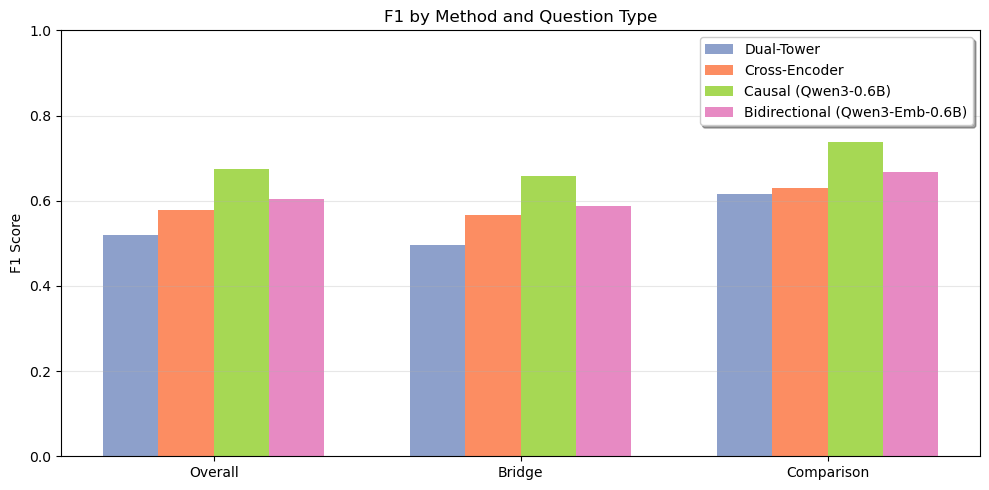

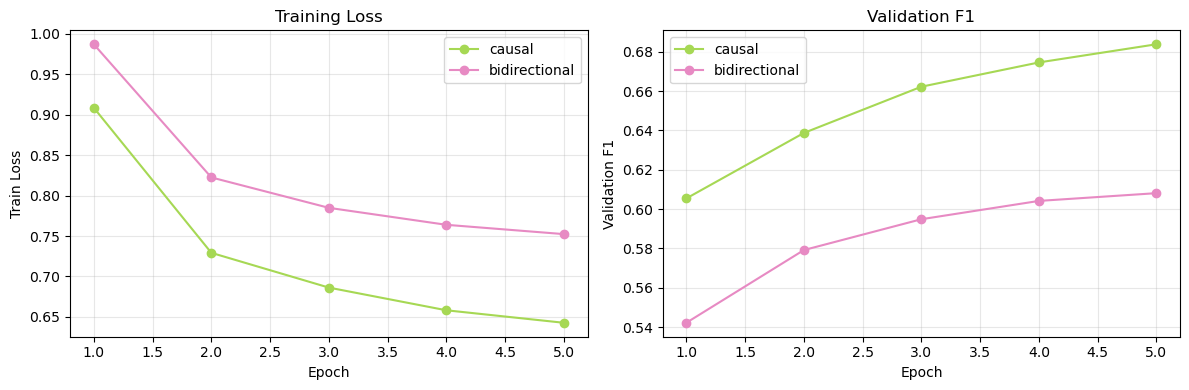

In [ ]:
import matplotlib.pyplot as plt
import json
import numpy as np
from pathlib import Path

plt.style.use("seaborn-v0_8-muted")
COLORS = ["#8da0cb", "#fc8d62", "#a6d854", "#e78ac3"]

runs_dir = Path("artifacts/runs")

# Load all test metrics from files
methods = {
    "Dual-Tower": json.loads((runs_dir / "dual_tower/test_metrics_tuned_threshold.json").read_text()),
    "Cross-Encoder": json.loads((runs_dir / "cross_encoder/test_metrics_tuned_threshold.json").read_text()),
    "Causal (Qwen3-0.6B)": json.loads((runs_dir / "causal/test_metrics_tuned_threshold.json").read_text()),
    "Bidirectional (Qwen3-Emb-0.6B)": json.loads((runs_dir / "bidirectional/test_metrics_tuned_threshold.json").read_text()),
}

# --- 1. F1 comparison bar chart ---
categories = ["Overall", "Bridge", "Comparison"]
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(categories))
width = 0.18

for i, (name, metrics) in enumerate(methods.items()):
    vals = [
        metrics["overall"]["f1"],
        metrics["by_question_type"]["bridge"]["f1"],
        metrics["by_question_type"]["comparison"]["f1"],
    ]
    ax.bar(x + i * width, vals, width, label=name, color=COLORS[i])

ax.set_ylabel("F1 Score")
ax.set_title("F1 by Method and Question Type")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(categories)
ax.legend(frameon=True, fancybox=True, shadow=True)
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(runs_dir / "f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 2. Training loss & validation F1 curves ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, model_key in enumerate(["causal", "bidirectional"]):
    history = json.loads((runs_dir / model_key / "training_history.json").read_text())["history"]
    epochs = [h["epoch"] for h in history]
    train_losses = [h["train_loss"] for h in history]
    val_f1s = [h["validation"]["overall"]["f1"] for h in history]

    axes[0].plot(epochs, train_losses, marker="o", label=model_key, color=COLORS[idx + 2])
    axes[1].plot(epochs, val_f1s, marker="o", label=model_key, color=COLORS[idx + 2])

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Train Loss")
axes[0].set_title("Training Loss")
axes[0].legend(frameon=True)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation F1")
axes[1].set_title("Validation F1")
axes[1].legend(frameon=True)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(runs_dir / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()